In [64]:
%reset -f

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt  
from matplotlib import colors as mcolors
from matplotlib.patches import FancyArrowPatch
import seaborn as sns
import warnings
from scipy.optimize import curve_fit
warnings.filterwarnings('ignore')

pd.set_option('mode.chained_assignment', None)
plt.rcParams["legend.frameon"] = False
plt.rcParams['savefig.dpi'] = 800
plt.rcParams['font.size'] = 13
plt.rcParams['font.family'] = 'Arial'

root_dir = '/Users/weiweizhan/Desktop/Weiwei_Zhan/Projects/WUE'

os.chdir(root_dir)

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
df_site    = pd.read_csv('./Data/results/sites_meta_info.csv',index_col=0)

df_SNR     = pd.read_csv('./Data/results/beta_SNR_results.csv',index_col=0)

df_delta_Y = pd.read_csv('./Data/results/delta_Y_CO2_results.csv',index_col=0)

## Fig 1: cross check of both methods

In [3]:
target      = 'iWUE'
resi_metric = 'beta'

y_SNR  = target+'_SNR'
y_beta = target+'_beta'
y_var  = y_SNR if resi_metric=='SNR' else y_beta

x_var  = f'delta_{target}_CO2'
assert df_SNR.index.equals(df_delta_Y.index)

df_plot = pd.concat([df_SNR[[y_SNR,y_beta]],df_delta_Y[x_var]],axis=1)

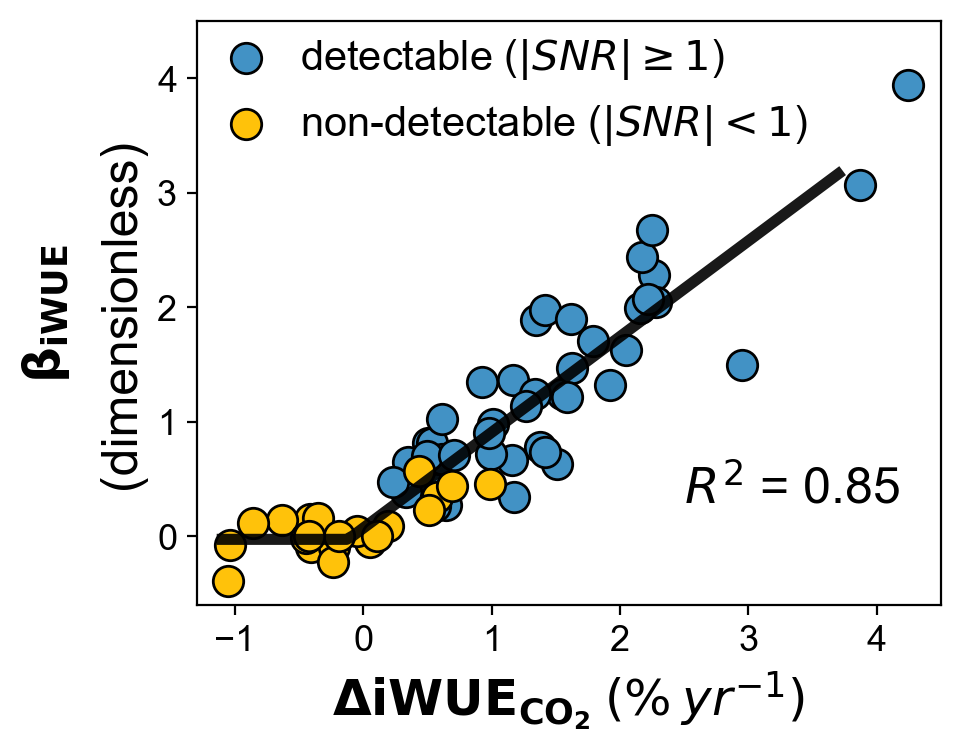

In [ ]:
fig,ax = plt.subplots(figsize=(5,4))

blue_c, yellow_c = '#4292C5','#FFC20A'
xmin,xmax = -1.3, 4.5
x = np.linspace(xmin,xmax, 100)

df_plot[df_plot[y_SNR]>1].plot(x_var,y_var,kind='scatter',ax=ax,color=blue_c,s=120,
                               edgecolor='black',label='detectable '+r'($|SNR| \geq 1$)') # 'detectable (|SNR|≥1)'
df_plot[df_plot[y_SNR]<1].plot(x_var,y_var,kind='scatter',ax=ax,color=yellow_c,s=120,
                               edgecolor='black',label='non-detectable '+r'($|SNR| < 1$)') #  'non-detectable (|SNR|<1)'
ax.legend(fontsize=15,bbox_to_anchor=(-0.04, 0.72),loc='lower left',
          handletextpad=0.3)

def piecewise_linear(x, x0, y0, k1):
    return np.piecewise(x, [x < x0], [lambda x:y0, lambda x:k1*x + y0-k1*x0])

x = df_plot[x_var].values
y = df_plot[y_var].values
p , e = curve_fit(piecewise_linear, x, y)
xd    = np.linspace(xmin+0.2, xmax-0.8, 100)
ax.plot(xd, piecewise_linear(xd, *p),linewidth=4,color='k',alpha=0.9)

y_fit = piecewise_linear(x, *p)
residuals = y - y_fit
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y - np.mean(y))**2)
r_squared = 1 - (ss_res / ss_tot)
ax.text(0.8, 0.2, f'$R^2$ = {r_squared:.2f}', 
        ha='center', va='center', transform=ax.transAxes,fontsize=18)

if resi_metric == 'SNR':
    ax.set_ylim([-1.5,3.5])
else:
    ax.set_ylim([-0.6,4.5])
    
ax.set_xlim([xmin,xmax])

ax.set_xlabel('$\mathbf{\Delta iWUE_{CO_2}} \: (\% \: yr^{-1})$',fontsize=18)

if resi_metric=='SNR':
    ylabel = '$\mathbf{{SNR}_{iWUE}}$ (dimensionless)'  
else: 
    ylabel = r'$\mathbf{{\beta}_{iWUE}}$'+'\n(dimensionless)' # 
    
ax.set_ylabel(ylabel,fontsize=18,linespacing=1.7) # 

plt.tight_layout()